# Exploration of Maczak PSD Processing Steps

This notebook explores the step-by-step transformation of a time series into a Power Spectral Density (PSD) using the **Maczak et al.** method implemented in `psd.py`.

We will use the preprocessed human data (`df_final`) as a test case.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loading import load_human_data
from src.data.preprocessing import preprocess_human, split_by_longest_gap
from src.PSD.psd import dft_single_sided_psd, _log_bin_edges, _bin_with_edges

## 1. Data Preparation
Replicating the preprocessing steps from `PSD.ipynb` to obtain `df_final`.

In [2]:
df_human = load_human_data()
df_human = preprocess_human(df_human, fs=1.0)
df_pre, df_post = split_by_longest_gap(df_human)
df_to_analyze = df_pre if len(df_pre) > len(df_post) else df_post
df_final = preprocess_human(df_to_analyze)

signal = df_final['temp_interp'].values
fs = 1.0
print(f"Signal length: {len(signal)} samples")

Total samples: 299880
NaN samples:   48272 (16.1%)
Number of gaps: 9
Gap lengths (samples): min=173, max=21364, median=3311
Longest gap: 5.93 hours

After interpolation:
Signal length: 299880 samples
Duration: 83.3 hours (3.5 days)
Sampling rate: 1.0 Hz
Remaining NaNs: 0
Longest gap found between indices 278516 and 299880
Gap length: 21364 samples
Segment 1: 278516 samples | Segment 2: 0 samples
Total samples: 278516
NaN samples:   26908 (9.7%)
Number of gaps: 8
Gap lengths (samples): min=173, max=13037, median=1977
Longest gap: 3.62 hours

After interpolation:
Signal length: 278516 samples
Duration: 77.4 hours (3.2 days)
Sampling rate: 1.0 Hz
Remaining NaNs: 0
Signal length: 278516 samples


## 2. Step 1: Raw Single-Sided PSD (DFT)
The first step is computing the Power Spectral Density using the Real FFT, normalized by $T/N^2$ and including the factor of 2 for energy conservation in single-sided spectra.

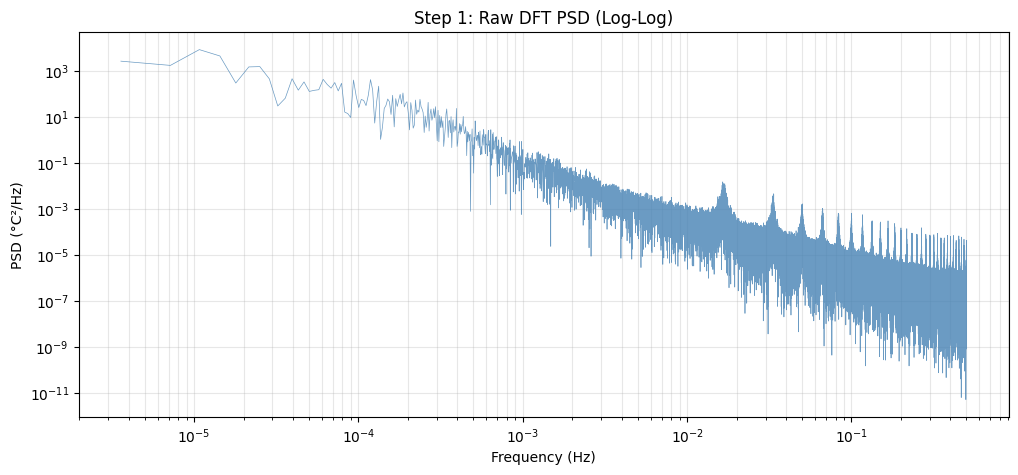

In [3]:
freqs_raw, psd_raw = dft_single_sided_psd(signal, fs)

f_plt = freqs_raw[1:]
p_plt = psd_raw[1:]

plt.figure(figsize=(12, 5))
plt.loglog(f_plt, p_plt, lw=0.5, alpha=0.8, color='steelblue')
plt.title("Step 1: Raw DFT PSD (Log-Log)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (\u00b0C\u00b2/Hz)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 3. Parameter Exploration: How Binning Affects the Result

Before applying the full Maczak pipeline, we explore how the key tunable parameters affect the output.

### `bins_per_decade` — the primary smoothing knob

Controls how many frequency bins cover one order of magnitude (e.g., from 0.001 Hz to 0.01 Hz).

| Setting | Effect | Risk |
|---|---|---|
| **Low** (e.g., 5) | Heavy smoothing, fewer points, loss of spectral detail | Merges distinct peaks (e.g., circadian + ultradian) into one broad hump |
| **High** (e.g., 50) | Fine resolution, close to raw DFT, little smoothing | Retains noise floor; harder to compare across subjects |
| **10–25** (typical) | Balanced: smooths noise while preserving physiological peaks | Recommended for 1 Hz signals over 1–7 days (Maczak et al.) |

### Other tunable parameters

**1. Binning mode (`"average"` vs `"median"`)**
- `"average"`: arithmetic mean of all PSD values in a bin. Mathematically clean but sensitive to spike artefacts.
- `"median"`: robust to isolated spectral spikes; useful for heavily artefacted data.

**2. Normalization strategy**
- **Sum-to-1** (used here): total power sums to 1. Emphasizes the *relative* shape of the spectrum. Enables cross-subject and cross-species comparison regardless of absolute temperature variance.
- **Max-to-1**: scales by the peak value. Preserves peak location but distorts the low-frequency shape.
- **None**: keeps absolute units (\u00b0C\u00b2/Hz). Required if you need to compare absolute power levels.

**3. Frequency range (`fmin`, `fmax`)**
- Determined by signal duration (`fmin \u2248 1/T`) and sampling rate (`fmax = fs/2`).
- For ensemble averaging, the **common range** across all subjects must be used — the shortest recording sets `fmin`.

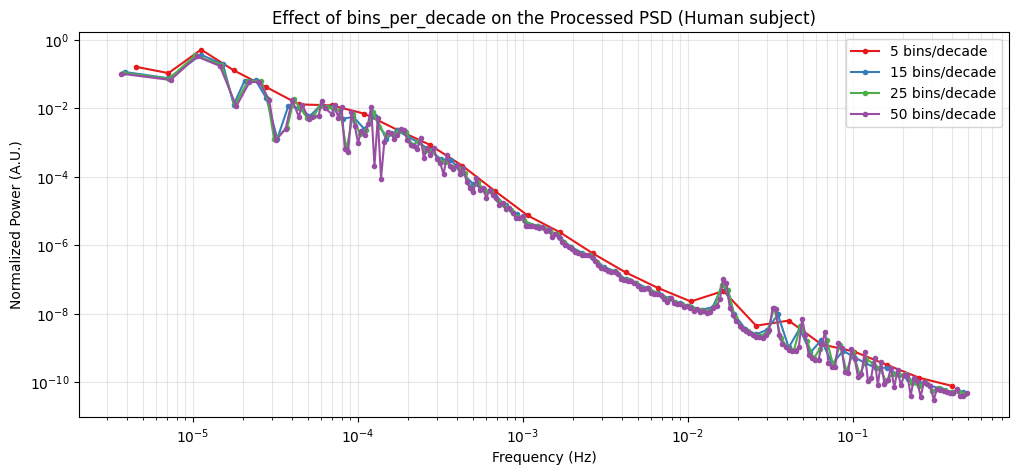

In [4]:
# --- Effect of bins_per_decade ---
bpd_values = [5, 15, 25, 50]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

plt.figure(figsize=(12, 5))
for bpd, col in zip(bpd_values, colors):
    edges_test = _log_bin_edges(f_plt.min(), f_plt.max(), bpd)
    f_b, p_b = _bin_with_edges(f_plt, p_plt, edges_test, mode="average")
    p_n = p_b / np.sum(p_b)
    plt.loglog(f_b, p_n, 'o-', markersize=3, lw=1.5, color=col,
               label=f"{bpd} bins/decade")

plt.title("Effect of bins_per_decade on the Processed PSD (Human subject)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power (A.U.)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

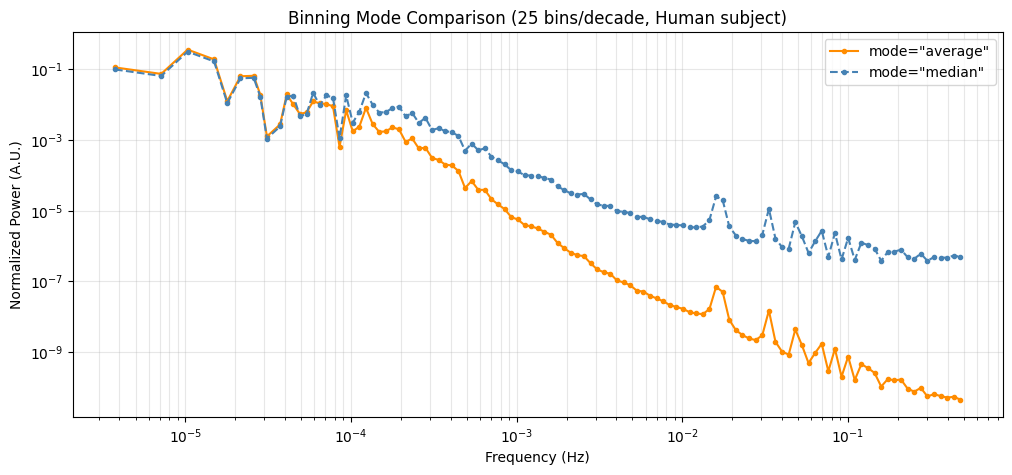

In [5]:
# --- Effect of binning mode ---
bpd_fixed = 25
edges_fixed = _log_bin_edges(f_plt.min(), f_plt.max(), bpd_fixed)

plt.figure(figsize=(12, 5))
for mode, col, ls in [("average", "darkorange", "-"), ("median", "steelblue", "--")]:
    f_b, p_b = _bin_with_edges(f_plt, p_plt, edges_fixed, mode=mode)
    p_n = p_b / np.sum(p_b)
    plt.loglog(f_b, p_n, 'o', markersize=3, lw=1.5, color=col,
               linestyle=ls, label=f'mode="{mode}"')

plt.title(f"Binning Mode Comparison ({bpd_fixed} bins/decade, Human subject)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power (A.U.)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

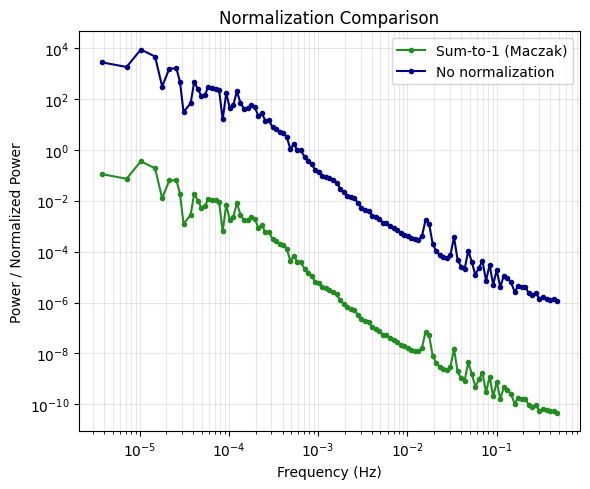

In [6]:
# --- Effect of normalization strategy (only Sum-to-1 vs No normalization) ---
bpd_fixed = 25
edges_fixed = _log_bin_edges(f_plt.min(), f_plt.max(), bpd_fixed)
f_b, p_b = _bin_with_edges(f_plt, p_plt, edges_fixed, mode="average")

p_sum1 = p_b / np.sum(p_b)
p_none = p_b

fig, ax = plt.subplots(figsize=(6, 5))

ax.loglog(f_b, p_sum1, 'o-', markersize=3, lw=1.5, color='forestgreen', label='Sum-to-1 (Maczak)')
ax.loglog(f_b, p_none, 'o-', markersize=3, lw=1.5, color='navy', label='No normalization')

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power / Normalized Power")
ax.set_title("Normalization Comparison")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

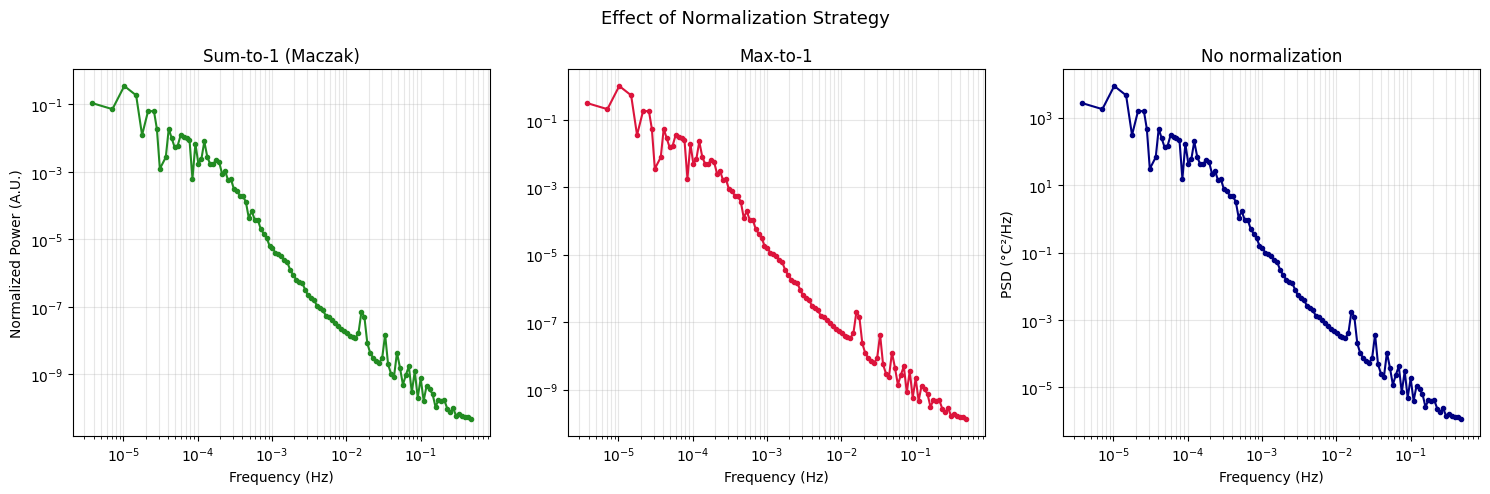

In [7]:
# --- Effect of normalization strategy ---
bpd_fixed = 25
edges_fixed = _log_bin_edges(f_plt.min(), f_plt.max(), bpd_fixed)
f_b, p_b = _bin_with_edges(f_plt, p_plt, edges_fixed, mode="average")

norm_strategies = {
    "Sum-to-1 (Maczak)": p_b / np.sum(p_b),
    "Max-to-1": p_b / np.max(p_b),
    "No normalization": p_b,
}
norm_colors = ['forestgreen', 'crimson', 'navy']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, p_norm), col in zip(axes, norm_strategies.items(), norm_colors):
    ax.loglog(f_b, p_norm, 'o-', markersize=3, lw=1.5, color=col)
    ax.set_title(label)
    ax.set_xlabel("Frequency (Hz)")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("Normalized Power (A.U.)")
axes[2].set_ylabel("PSD (\u00b0C\u00b2/Hz)")
fig.suptitle("Effect of Normalization Strategy", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Step 2: Logarithmic Binning (LBBA)
Linear frequency spacing in DFT causes an over-representation of high frequencies in log-plots. Maczak's method uses logarithmic binning (LBBA - Logarithmic Bin-Based Averaging) to smooth the spectrum and equalize weight across decades.

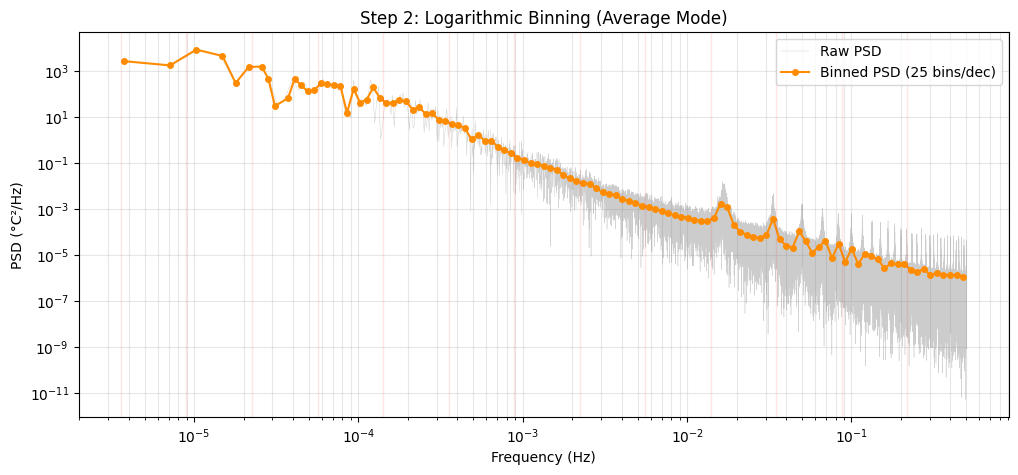

In [8]:
bins_per_decade = 25
edges = _log_bin_edges(f_plt.min(), f_plt.max(), bins_per_decade)
f_bin, psd_bin = _bin_with_edges(f_plt, p_plt, edges, mode="average")

plt.figure(figsize=(12, 5))
plt.loglog(f_plt, p_plt, lw=0.3, alpha=0.4, color='gray', label="Raw PSD")
plt.loglog(f_bin, psd_bin, 'o-', markersize=4, lw=1.5, color='darkorange',
           label=f"Binned PSD ({bins_per_decade} bins/dec)")

for edge in edges[::10]:
    plt.axvline(edge, color='red', alpha=0.1, lw=1)

plt.title("Step 2: Logarithmic Binning (Average Mode)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (\u00b0C\u00b2/Hz)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 5. Step 3: Normalization
To compare spectra from different subjects or sessions, Maczak normalizes the binned PSD so that the total power (sum of values) equals 1.

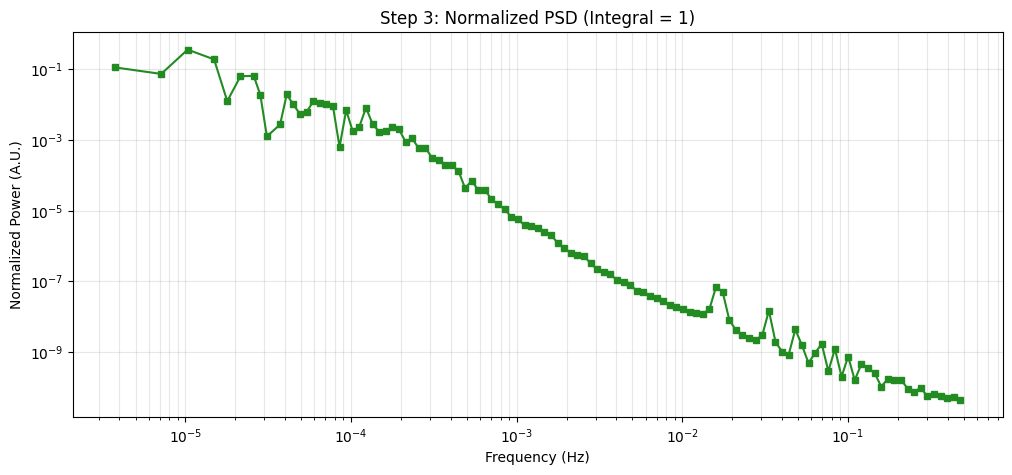

In [9]:
psd_norm = psd_bin / np.sum(psd_bin)

plt.figure(figsize=(12, 5))
plt.loglog(f_bin, psd_norm, 's-', markersize=4, lw=1.5, color='forestgreen')
plt.title("Step 3: Normalized PSD (Integral = 1)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power (A.U.)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Summary Comparison
Visualizing the raw data vs the processed ensemble candidate.

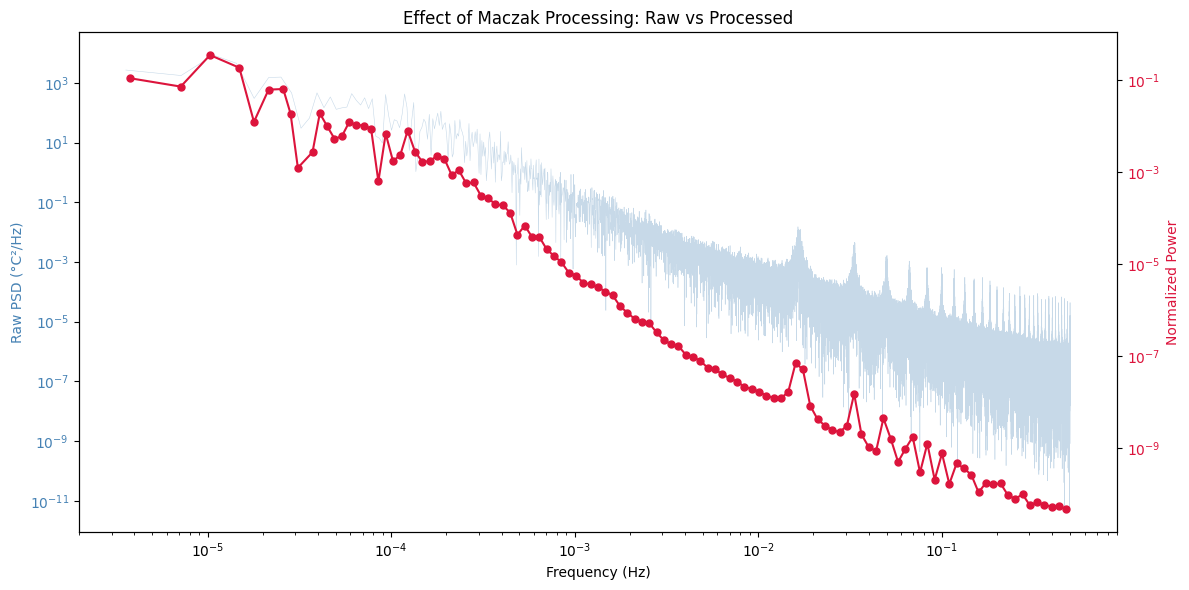

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.loglog(f_plt, p_plt, lw=0.4, alpha=0.3, color='steelblue', label="Raw (LHS Axis)")
ax1.set_ylabel("Raw PSD (\u00b0C\u00b2/Hz)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.loglog(f_bin, psd_norm, 'o-', markersize=5, color='crimson', label="Maczak Processed (RHS Axis)")
ax2.set_ylabel("Normalized Power", color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title("Effect of Maczak Processing: Raw vs Processed")
ax1.set_xlabel("Frequency (Hz)")
fig.tight_layout()
plt.show()

## 6. Multi-Subject Exploration: Cheetah
Now we see the effect of the Maczak workflow when applied to multiple individuals (Ensemble Average). This is where the method truly shines by reducing inter-individual noise and highlighting common spectral features.

In [11]:
from src.data.loading import load_species_excel
from src.data.preprocessing import clean_species_outliers

species_data = load_species_excel()
species_data_clean = clean_species_outliers(species_data, sigma=4.0)

specie_name = 'Cheetah'
df_cheetah = species_data_clean[specie_name]
fs_cheetah = 1/60.0

signals_cheetah = []
subject_ids = []
for col in df_cheetah.columns:
    if col != 'Hour':
        s = df_cheetah[col].dropna().values
        if len(s) > 100:
            signals_cheetah.append(s)
            subject_ids.append(col)

print(f"Loaded {len(signals_cheetah)} subjects for {specie_name}")

Alpaca               | Alpaca 14       |  12 outliers replaced (threshold: 37.91 ± 2.05 °C)
Pekin duck           | Duck 1          |   3 outliers replaced (threshold: 40.51 ± 1.33 °C)
Pekin duck           | Duck 5          |   1 outliers replaced (threshold: 40.88 ± 1.20 °C)
Pekin duck           | Duck 6          |   1 outliers replaced (threshold: 40.73 ± 1.61 °C)
Pekin duck           | Duck 14         |   1 outliers replaced (threshold: 40.19 ± 1.66 °C)
Rabbit               | Rabbit 1        |   1 outliers replaced (threshold: 39.67 ± 1.18 °C)
Sheep                | Sheep 8         |  12 outliers replaced (threshold: 38.55 ± 0.82 °C)
Sheep                | Sheep 9         |  10 outliers replaced (threshold: 38.46 ± 0.75 °C)
Blue wildebeest      | Blue wildebeest 3 |   2 outliers replaced (threshold: 39.09 ± 1.12 °C)
Blue wildebeest      | Blue wildebeest 5 |   3 outliers replaced (threshold: 39.08 ± 1.28 °C)
Blue wildebeest      | Blue wildebeest 6 |   1 outliers replaced (threshold:

### Step 1: Overlapping Raw Individual PSDs
We calculate the PSD for each subject independently. Notice the variance and the high-frequency 'noise' floor.

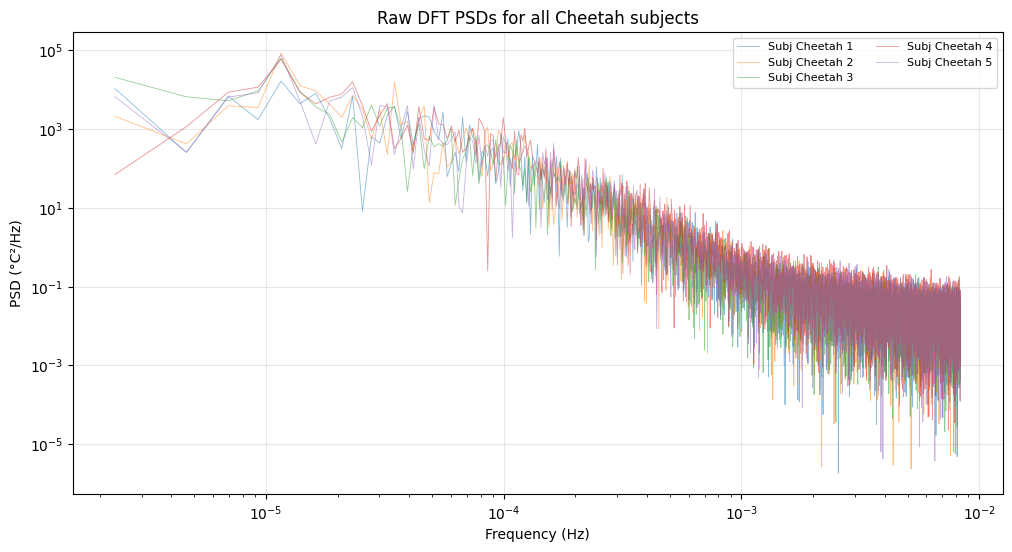

In [12]:
individual_psds = []
for s in signals_cheetah:
    f_raw, p_raw = dft_single_sided_psd(s, fs_cheetah)
    individual_psds.append((f_raw[1:], p_raw[1:]))

plt.figure(figsize=(12, 6))
for i, (f, p) in enumerate(individual_psds):
    plt.loglog(f, p, lw=0.6, alpha=0.5, label=f"Subj {subject_ids[i]}")

plt.title(f"Raw DFT PSDs for all {specie_name} subjects")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (\u00b0C\u00b2/Hz)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

### Final Step: Binning, Normalization and Ensemble Averaging
Applying the full Maczak pipeline: individual spectra are smoothed (log-binning), brought to the same scale (normalization), and finally averaged to create the ensemble signature.

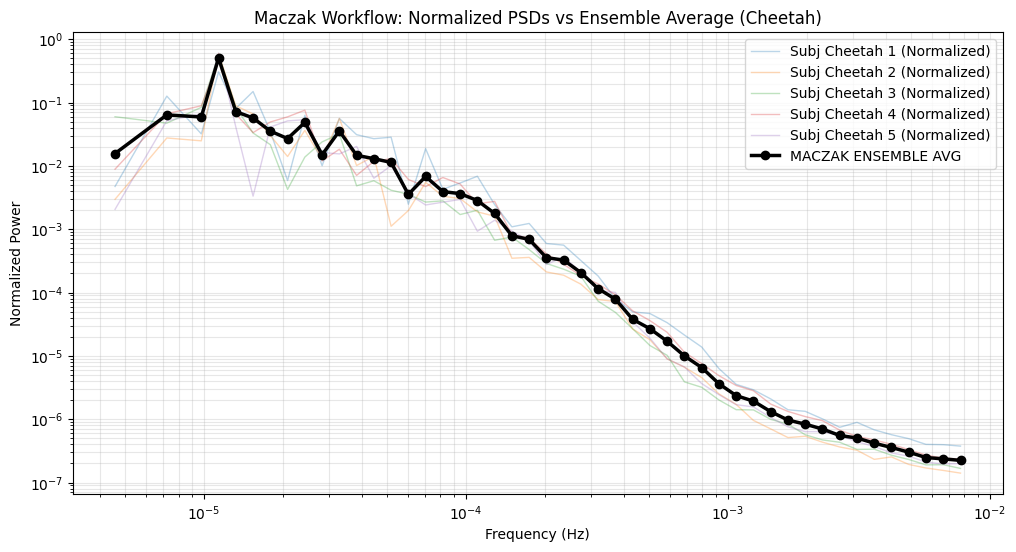

In [13]:
fmin_c = max(np.min(f) for f, _ in individual_psds)
fmax_c = min(np.max(f) for f, _ in individual_psds)
edges_c = _log_bin_edges(fmin_c, fmax_c, bins_per_decade=15)

normalized_psds = []
common_f_c = None

for f_raw, p_raw in individual_psds:
    f_b, p_b = _bin_with_edges(f_raw, p_raw, edges_c, mode="average")
    p_n = p_b / np.sum(p_b)
    normalized_psds.append(p_n)
    if common_f_c is None:
        common_f_c = f_b

ensemble_p = np.mean(np.vstack(normalized_psds), axis=0)

plt.figure(figsize=(12, 6))
for i, p_n in enumerate(normalized_psds):
    plt.loglog(common_f_c, p_n, lw=1, alpha=0.3,
               label=f"Subj {subject_ids[i]} (Normalized)")

plt.loglog(common_f_c, ensemble_p, 'o-', color='black', lw=2.5,
           markersize=6, label="MACZAK ENSEMBLE AVG")

plt.title(f"Maczak Workflow: Normalized PSDs vs Ensemble Average ({specie_name})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Parametrization - beta calculation